# Physics + data: combining an ITU-R branch with a learned one

Two questions on synthetic links, where the truth is known:

1. **How should a physics estimate and a data-driven estimate be combined?**
   Six strategies, from the power law alone to a residual network, over
   frequency and sensor noise (`src/mixing.py`).
2. **Does the hybrid physics + GRU model beat its own physics branch, and
   does training it in stages help?** (`src/hybrid_training.py`, the model in
   `src/hybrid_nn.py`).

The concise counterpart of `Simulation_MBML.ipynb`, which is kept as the
original working record. Everything shown here is computed in this notebook.

In [1]:
import sys
from pathlib import Path

import numpy as np

sys.path.insert(0, str(Path.cwd().parent / "src"))
from core import viz_style as vs
import hybrid_training as ht
import mixing
import plots
from rain_simulator import RainAttenuationGenerator, rain_params_from_itu

vs.use_style()

## Synthetic links

Rain from a gamma distribution, attenuation from the ITU-R power law over a
1 km path, plus Gaussian sensor noise at three levels.

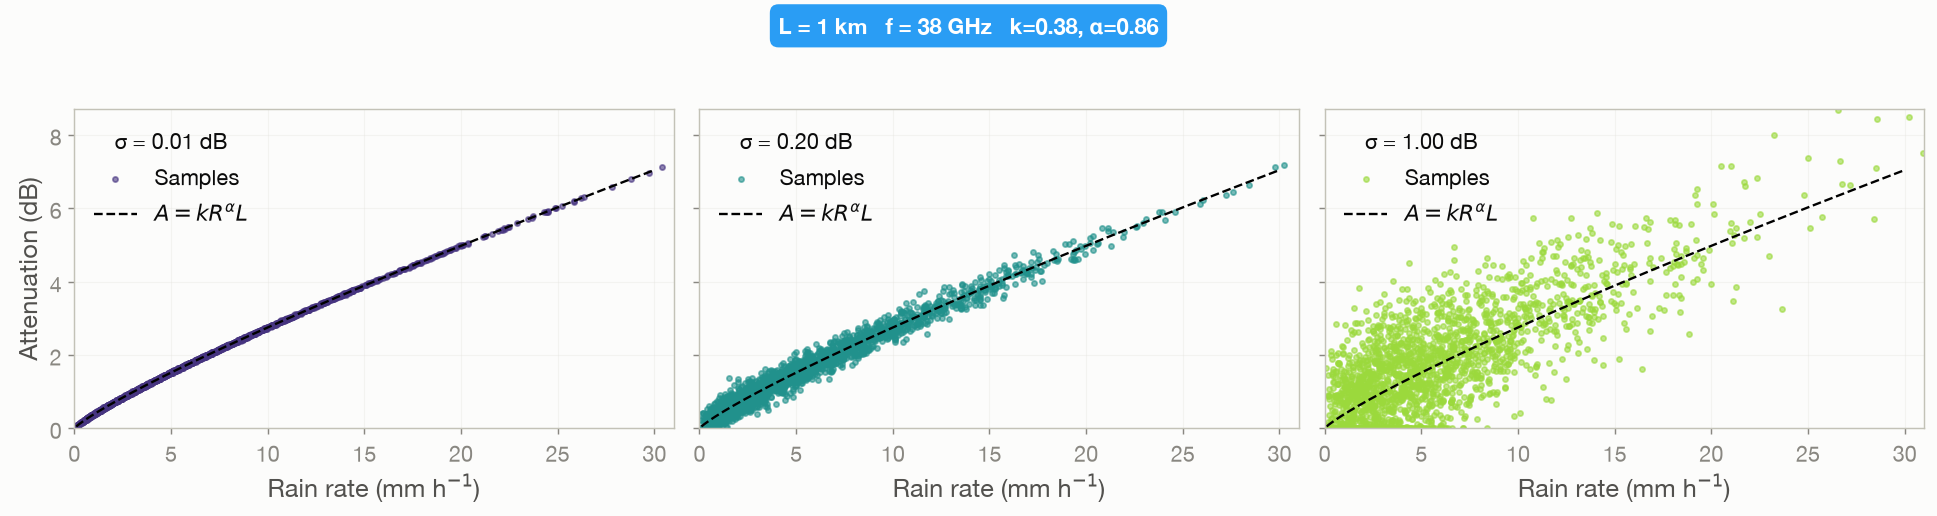

In [2]:
gen = RainAttenuationGenerator(seed=42)
gen.plot_noise_comparison(sigma_vals=[0.01, 0.2, 1.0], rain_params=rain_params_from_itu(38),
                          link_length_km=1.0, freq_ghz=38, n_samples=2000,
                          rain_sampler=lambda n: gen._rain_gamma(n, shape=1.5, scale=4.0));

## 1. Six ways to combine the branches

100 samples per draw, 5 repeats per (frequency, noise), noise from 0 to 1 dB.

In [3]:
table = mixing.sweep(frequencies=(5, 23, 60, 70), noise_db=np.linspace(0.001, 1.0, 20), repeats=5)
mixing.summary(table).round(2)

mean MSE                                      share of draws won  \
          physics    mlp scalar   gate     fc residual                 fc   
freq_ghz                                                                    
5         3137.14  74.05  70.59  71.12  87.09   166.92               0.10   
23          16.36  13.29  13.24  13.58  14.53    13.30               0.12   
60           2.65   2.78   2.54   2.51   3.19     2.65               0.04   
70           2.34   2.58   2.26   2.22   2.93     2.36               0.01   

                                              
          gate   mlp physics residual scalar  
freq_ghz                                      
5         0.41  0.41    0.01     0.02   0.05  
23        0.18  0.14    0.25     0.28   0.03  
60        0.36  0.14    0.27     0.11   0.08  
70        0.37  0.11    0.29     0.11   0.11

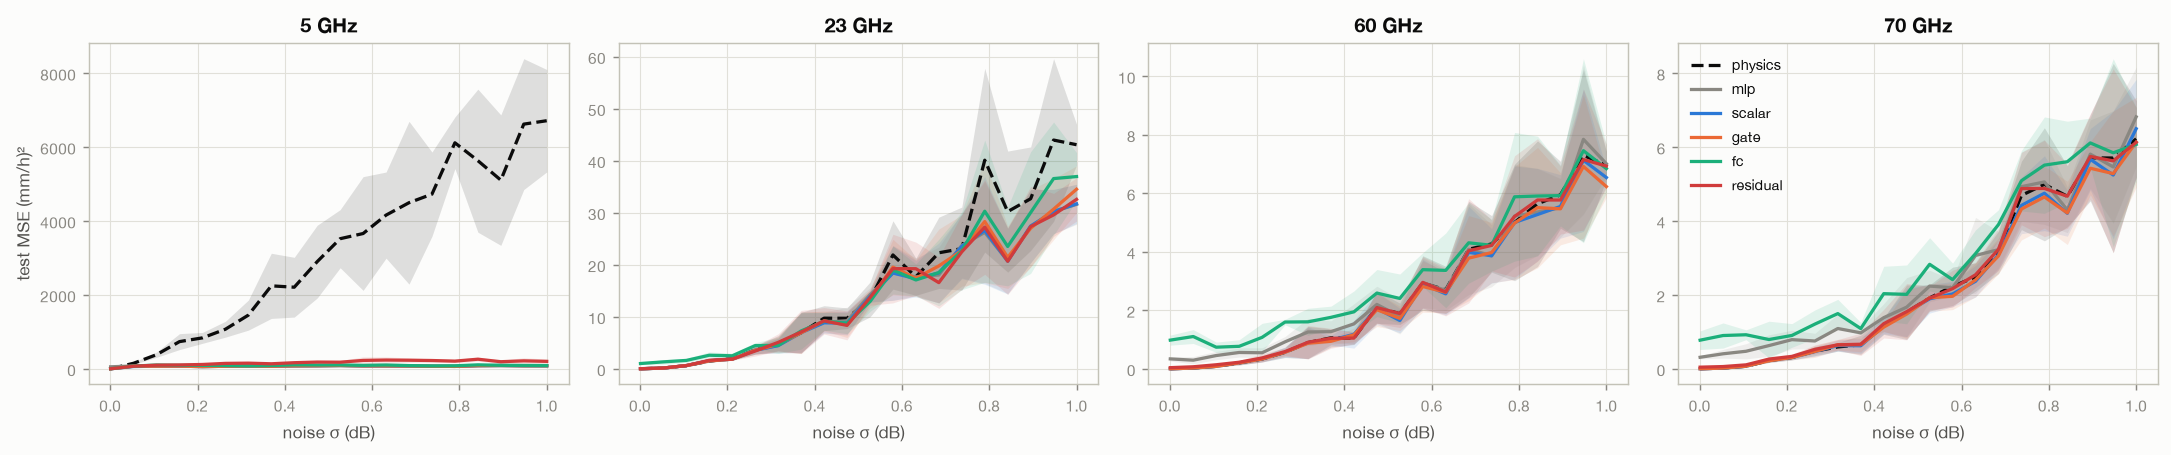

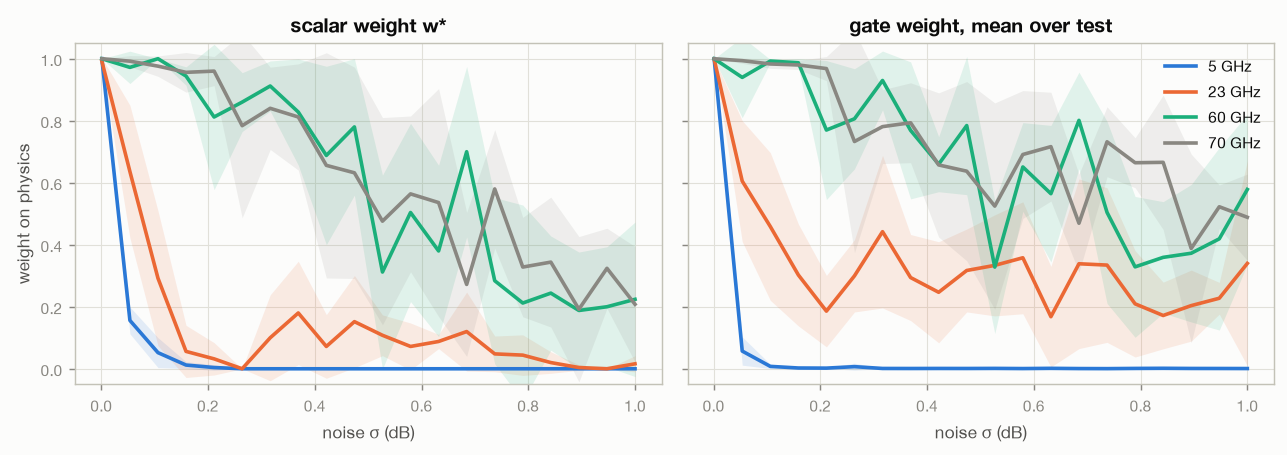

In [4]:
plots.mixing_vs_noise(table);
plots.weights_vs_noise(table);

**Frequency decides it.** At 5 GHz a 1 km link attenuates so weakly that
inverting the power law amplifies noise into an MSE of ~3,000; every learned
strategy is ~40x better, and the fitted weight on physics drops to ~0 above
0.05 dB. The residual hybrid is the exception, because it inherits the
physics error it only corrects. At 60-70 GHz physics alone is within ~5% of
the best, the learned gate edges it (MSE 2.51 vs 2.65, 2.22 vs 2.34), and
the weight on physics falls only gradually with noise. 23 GHz sits between:
all learned strategies tie near 13, physics is ~25% worse.

## 2. The hybrid physics + GRU model: staged vs joint training

38 GHz, four noise levels, the original notebook's budget: staged is 8 epochs
on the branches, 5 on the gate, 7 joint; joint is 20 epochs from the start.
Both start from the same initialization.

In [5]:
results, runs = ht.compare_over_noise(38, noise_levels=(0.05, 0.5, 1.0, 2.0))
results.round(3)

fused  physics  neural   gate      k  alpha  k_itu  alpha_itu
noise_db method                                                               
0.05     staged  4.003    0.487   4.042  0.130  0.415  0.832  0.384      0.855
         joint   5.388    0.551   5.445  0.116  0.395  0.855  0.384      0.855
0.50     staged  4.118    1.261   4.157  0.134  0.399  0.858  0.384      0.855
         joint   5.390    1.270   5.443  0.118  0.392  0.864  0.384      0.855
1.00     staged  4.343    2.238   4.379  0.156  0.401  0.878  0.384      0.855
         joint   5.400    2.252   5.441  0.123  0.393  0.874  0.384      0.855
2.00     staged  4.677    3.738   4.727  0.227  0.416  0.922  0.384      0.855
         joint   5.460    4.124   5.466  0.137  0.396  0.881  0.384      0.855

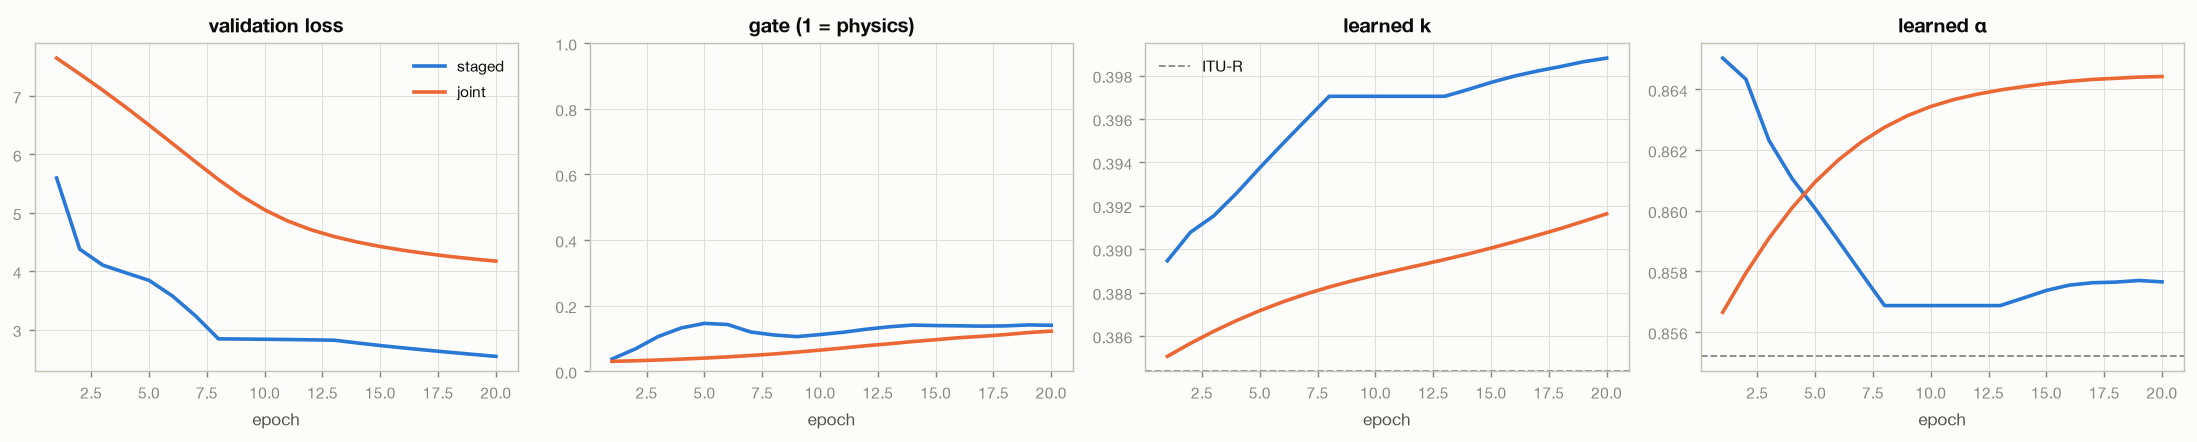

In [6]:
plots.training_histories(runs[0.5], itu=(results.k_itu.iloc[0], results.alpha_itu.iloc[0]));

**The fused output is worse than the physics branch alone at every noise
level**, and the gate stays near the neural branch (0.1-0.2) even though the
physics branch is several times more accurate. Staged training is better
than joint throughout, and the learnable power law stays close to ITU-R.

A likely cause is the input, not the training: `hybrid_nn.prepare_sequences`
builds each "sequence" as random noise around one attenuation value, so the
GRU has no temporal information to use, and the gate learns to trust a
branch that cannot be right. The original notebook's summary tables (cells
17, 18 and 22) show the hybrid ahead; those numbers are typed in, not
computed there, and are not reproduced by this code.